Link:  https://www.kaggle.com/code/yukawithdata/beyonce-s-track-data-exploration

In [3]:
#Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [4]:
df = pd.read_csv("C:/Users/DELL-PC/Desktop/PGDM/Other/beyonce_tracks.csv")
df
df.head()

,artist_name,track_name,album_name,is_explicit,genres,release_date,track_id,danceability,valence,energy,loudness,acousticness,instrumentalness,liveness,speechiness,key,tempo,mode,duration_ms,time_signature
0,Beyoncé,I'M THAT GIRL,RENAISSANCE,True,"pop, r&b",2022-07-29,1MpCaOeUWhox2Fgigbe1cL,0.554,0.136,0.535,-8.959,0.061600,0.000013,0.1240,0.1860,5,105.865,0,208014,4
1,Beyoncé,COZY,RENAISSANCE,True,"pop, r&b",2022-07-29,0mKGwFMHzTprtS2vpR3b6s,0.556,0.367,0.630,-8.150,0.000828,0.004680,0.1550,0.1020,7,149.147,1,210372,5
2,Beyoncé,ALIEN SUPERSTAR,RENAISSANCE,True,"pop, r&b",2022-07-29,1Hohk6AufHZOrrhMXZppax,0.545,0.464,0.641,-6.398,0.004530,0.000066,0.1710,0.0998,10,121.892,0,215460,4
3,Beyoncé,CUFF IT,RENAISSANCE,True,"pop, r&b",2022-07-29,1xzi1Jcr7mEi9K2RfzLOqS,0.780,0.642,0.689,-5.668,0.036800,0.000010,0.0698,0.1410,7,115.042,1,225389,4
4,"Beyoncé, BEAM",ENERGY (feat. Beam),RENAISSANCE,False,"pop, r&b",2022-07-29,0314PeD1sQNonfVWix3B2K,0.903,0.587,0.519,-9.151,0.281000,0.000106,0.1550,0.2600,1,114.991,1,116727,4


In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist_name       336 non-null    object 
 1   track_name        336 non-null    object 
 2   album_name        336 non-null    object 
 3   is_explicit       336 non-null    bool   
 4   genres            336 non-null    object 
 5   release_date      336 non-null    object 
 6   track_id          336 non-null    object 
 7   danceability      336 non-null    float64
 8   valence           336 non-null    float64
 9   energy            336 non-null    float64
 10  loudness          336 non-null    float64
 11  acousticness      336 non-null    float64
 12  instrumentalness  336 non-null    float64
 13  liveness          336 non-null    float64
 14  speechiness       336 non-null    float64
 15  key               336 non-null    int64  
 16  tempo             336 non-null    float64
 1

(336, 20)

In [6]:
#Duplicated rows
df.duplicated().sum()

0

In [7]:
#Duplicated rows with same tracks
duplicated_tracks = df['track_name'].duplicated(keep=False)
print(f"Number of matching track names: {duplicated_tracks.sum()}")

Number of matching track names: 84


In [8]:
df.nunique()

artist_name          80
track_name          290
album_name           49
is_explicit           2
genres                1
release_date         47
track_id            336
danceability        244
valence             271
energy              264
loudness            329
acousticness        311
instrumentalness    234
liveness            281
speechiness         280
key                  12
tempo               330
mode                  2
duration_ms         321
time_signature        4
dtype: int64

In [9]:
df['time_signature'].unique()

array([4, 5, 3, 1], dtype=int64)

In [10]:
#Getting duplicated track name values
if duplicated_tracks.sum() >0:
    duplicated_tracks_df = df[duplicated_tracks].sort_values(by='track_name')
    print(duplicated_tracks_df[['artist_name', 'track_name', 'album_name', 'release_date','genres']])

                           artist_name               track_name  \
30   Beyoncé, Shatta Wale, Major Lazer                  ALREADY   
20   Beyoncé, Shatta Wale, Major Lazer                  ALREADY   
272       Beyoncé, Alejandro Fernández              Amor Gitano   
185       Beyoncé, Alejandro Fernández              Amor Gitano   
16                             Beyoncé                   BIGGER   
..                                 ...                      ...   
194                            Beyoncé                Suga Mama   
242                            Beyoncé             Sweet Dreams   
164                            Beyoncé             Sweet Dreams   
174                     Beyoncé, JAY-Z  Upgrade U (feat. Jay-Z)   
195                     Beyoncé, JAY-Z  Upgrade U (feat. Jay-Z)   

                                   album_name release_date    genres  
30                    The Lion King: The Gift   2019-07-19  pop, r&b  
20   The Lion King: The Gift [Deluxe Edition]   2020-

In [11]:
duplicated_tracks_df
#as the data here is not same for the tracks, im not deleting the data

,artist_name,track_name,album_name,is_explicit,genres,release_date,track_id,danceability,valence,energy,loudness,acousticness,instrumentalness,liveness,speechiness,key,tempo,mode,duration_ms,time_signature
30,"Beyoncé, Shatta Wale, Major Lazer",ALREADY,The Lion King: The Gift,False,"pop, r&b",2019-07-19,6tgEc2O1uFHcZDKPoo6PC8,0.647,0.548,0.732,-5.846,0.08460,0.000000,0.5970,0.0891,2,67.295,1,222529,3
20,"Beyoncé, Shatta Wale, Major Lazer",ALREADY,The Lion King: The Gift [Deluxe Edition],False,"pop, r&b",2020-07-31,1TSinFFcDJJzR6ErO81Y3c,0.671,0.543,0.755,-5.831,0.08760,0.000000,0.4290,0.0683,2,67.332,0,223422,3
272,"Beyoncé, Alejandro Fernández",Amor Gitano,Irreemplazable,False,"pop, r&b",2007-08-27,2N1D0rf5uu3kYLxgEXWB8E,0.390,0.627,0.758,-5.687,0.45700,0.000000,0.1880,0.3220,4,168.128,0,228413,4
185,"Beyoncé, Alejandro Fernández",Amor Gitano,B'Day Deluxe Edition,False,"pop, r&b",2007-05-29,1Kd5Qj9kicqjCw1BjWRzH0,0.491,0.596,0.745,-5.631,0.47300,0.000000,0.2390,0.2540,4,167.875,0,228413,4
16,Beyoncé,BIGGER,The Lion King: The Gift [Deluxe Edition],False,"pop, r&b",2020-07-31,0gdOcxvPU37ADE7vPkgQsv,0.509,0.181,0.360,-8.200,0.63300,0.000000,0.1300,0.0361,5,129.624,0,226361,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Beyoncé,Suga Mama,B'Day,False,"pop, r&b",2006-09-04,7hrrhtzmyTcULmNlYlcxJO,0.682,0.615,0.939,-4.054,0.22600,0.000315,0.3460,0.2840,9,93.810,0,204813,4
242,Beyoncé,Sweet Dreams,Ego/Sweet Dreams Singles & Dance Mixes,False,"pop, r&b",2009-07-21,3BwDtDoQJjo8lsSMTMuUHg,0.693,0.755,0.819,-6.001,0.10300,0.000016,0.0637,0.1010,1,121.968,1,209213,4
164,Beyoncé,Sweet Dreams,I AM...SASHA FIERCE,False,"pop, r&b",2008-11-14,1FKxKGONukVFXWVJxAKmlz,0.694,0.788,0.825,-5.986,0.08950,0.000019,0.0618,0.1110,1,121.949,1,208067,4
174,"Beyoncé, JAY-Z",Upgrade U (feat. Jay-Z),B'Day Deluxe Edition,False,"pop, r&b",2007-05-29,0GLUBbX4daHJkT3RQHEOia,0.593,0.483,0.680,-5.556,0.00182,0.000048,0.3100,0.3350,7,84.547,1,273053,4


In [12]:
#Data wrangling

In [13]:
#converting data types
df['release_date'] = pd.to_datetime(df['release_date'])
df['key'] = df['key'].astype('category')
df['time_signature'] = df['time_signature'].astype('category')
df['mode'] = df['mode'].astype('category')
print(df.dtypes)

artist_name                 object
track_name                  object
album_name                  object
is_explicit                   bool
genres                      object
release_date        datetime64[ns]
track_id                    object
danceability               float64
valence                    float64
energy                     float64
loudness                   float64
acousticness               float64
instrumentalness           float64
liveness                   float64
speechiness                float64
key                       category
tempo                      float64
mode                      category
duration_ms                  int64
time_signature            category
dtype: object


In [14]:
df.columns

Index(['artist_name', 'track_name', 'album_name', 'is_explicit', 'genres',
       'release_date', 'track_id', 'danceability', 'valence', 'energy',
       'loudness', 'acousticness', 'instrumentalness', 'liveness',
       'speechiness', 'key', 'tempo', 'mode', 'duration_ms', 'time_signature'],
      dtype='object')

# Distribution of Numeric Features

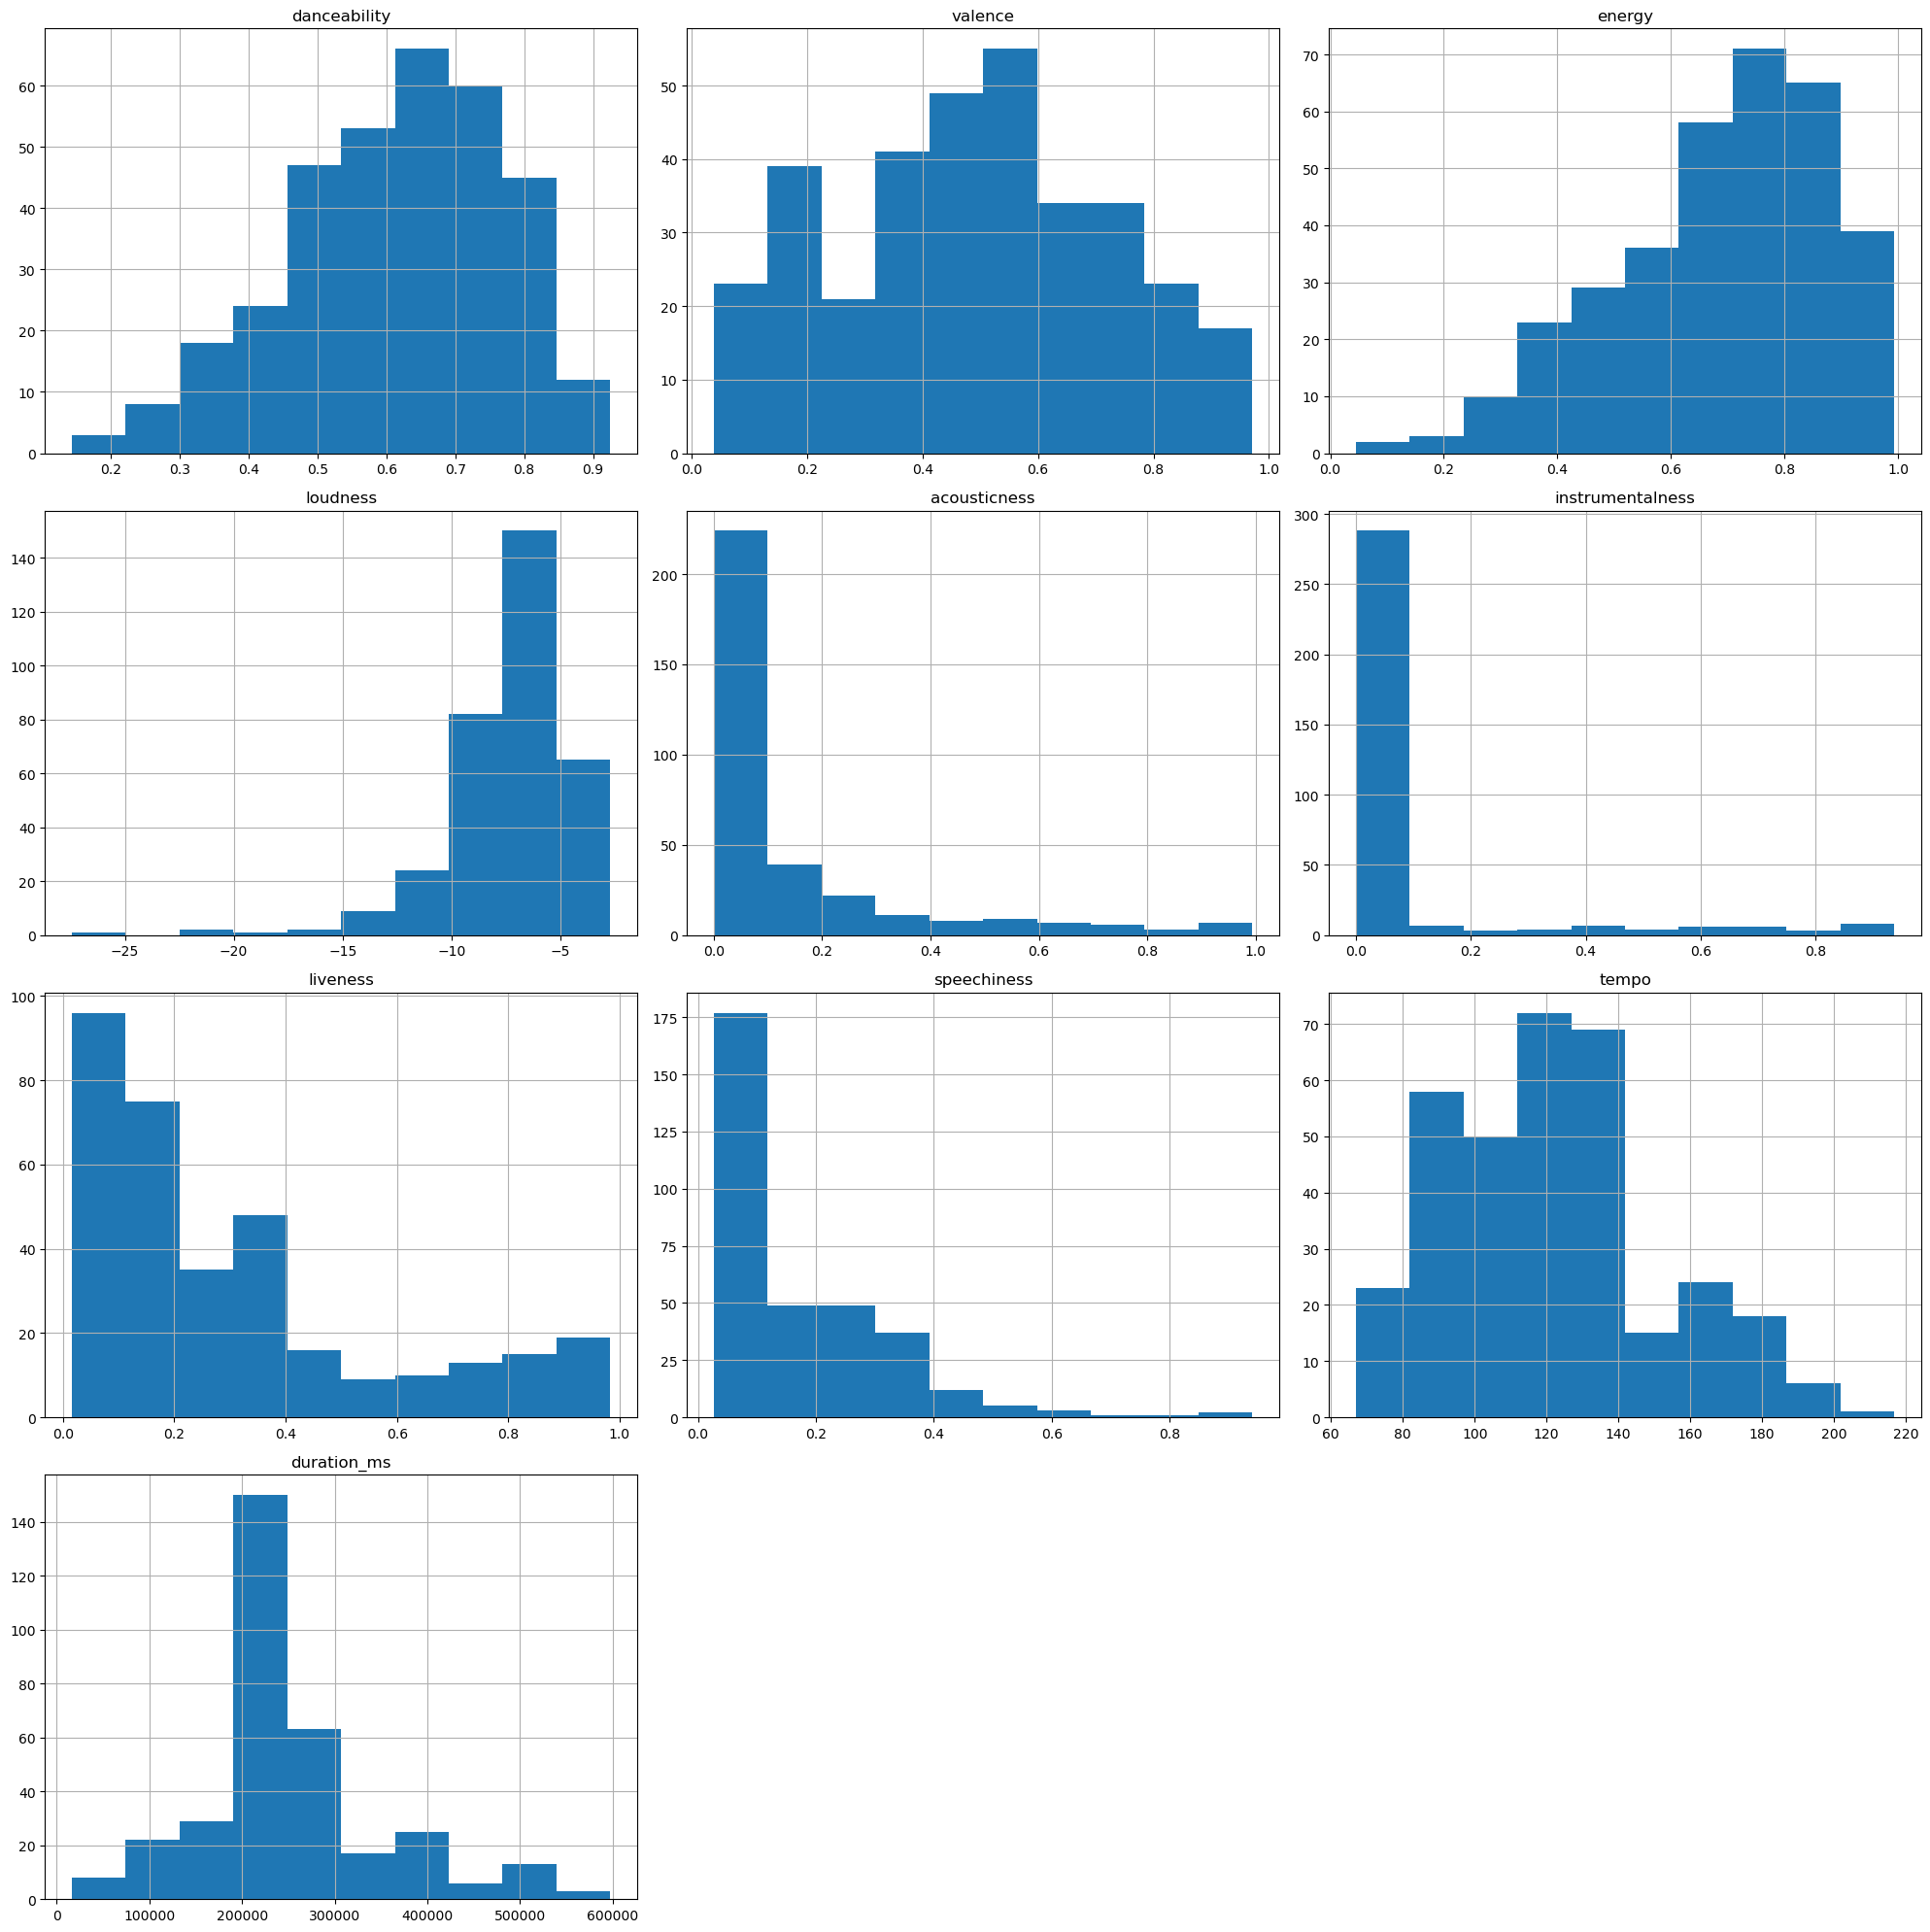

In [15]:
num_col = ['danceability', 'valence', 'energy',
       'loudness', 'acousticness', 'instrumentalness', 'liveness',
       'speechiness','tempo','duration_ms']
df[num_col].hist(figsize = (20,20))
plt.tight_layout()
plt.show()

# Trends Over Time

In [16]:
sns.set_palette('Paired')

    year    energy
0   2002  0.750000
1   2003  0.482482
2   2004  0.471500
3   2006  0.773878
4   2007  0.754348
5   2008  0.545882
6   2009  0.749465
7   2010  0.772269
8   2011  0.709778
9   2014  0.553550
10  2016  0.486000
11  2019  0.697809
12  2020  0.534800
13  2022  0.710650
14  2023  0.604833
15  2024  0.515500


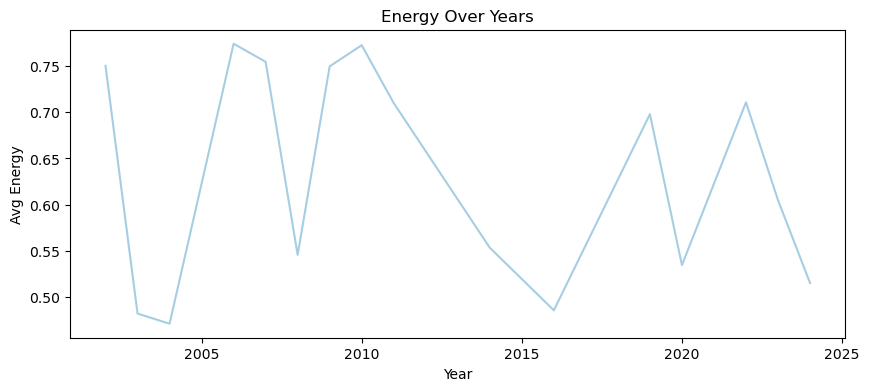

In [17]:
df['year'] = df['release_date'].dt.year
energy_trend = df.groupby('year')['energy'].mean().reset_index()
print(energy_trend)
plt.figure(figsize = (10,4))
sns.lineplot(x = 'year', y = 'energy',data =energy_trend)
plt.title('Energy Over Years')
plt.xlabel('Year')
plt.ylabel('Avg Energy')
plt.show()

    year   valence
0   2002  0.660250
1   2003  0.571176
2   2004  0.557500
3   2006  0.567366
4   2007  0.542022
5   2008  0.394294
6   2009  0.689984
7   2010  0.275908
8   2011  0.554333
9   2014  0.374385
10  2016  0.399031
11  2019  0.400281
12  2020  0.317290
13  2022  0.462525
14  2023  0.492167
15  2024  0.399250


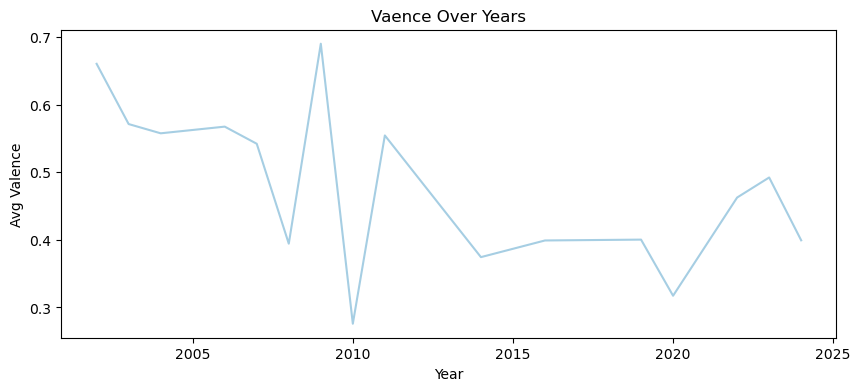

In [18]:
valence_trend = df.groupby('year')['valence'].mean().reset_index()
print(valence_trend)

plt.figure(figsize = (10,4))
sns.lineplot(x = 'year', y = 'valence',data =valence_trend)
plt.title('Vaence Over Years')
plt.xlabel('Year')
plt.ylabel('Avg Valence')
plt.show()

C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_31740\2086539907.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  yearly_means = df.groupby('year')['energy','danceability','acousticness', 'speechiness', 'valence','instrumentalness'].mean().reset_index()


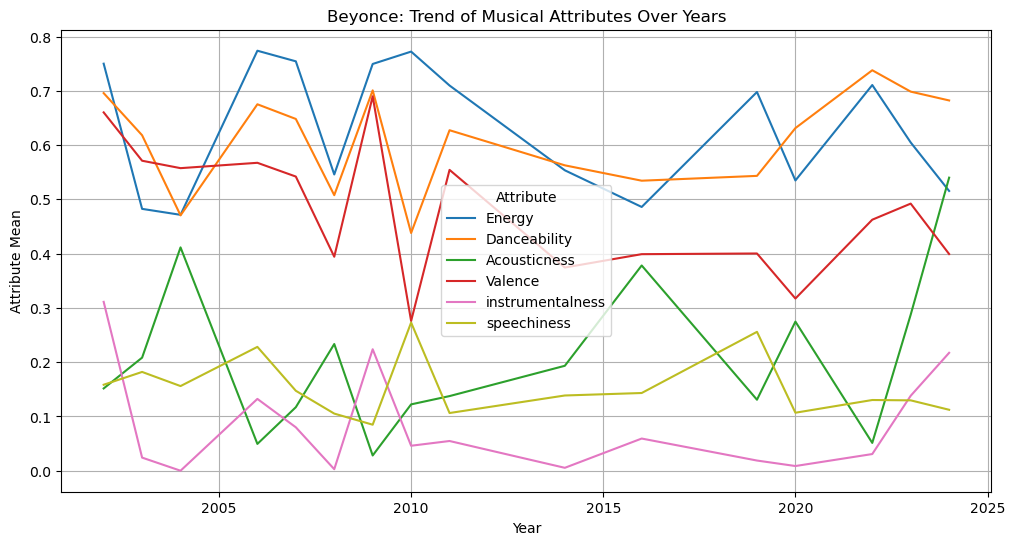

In [19]:
yearly_means = df.groupby('year')['energy','danceability','acousticness', 'speechiness', 'valence','instrumentalness'].mean().reset_index()
plt.figure(figsize=(12,6))
#energy
sns.lineplot(x='year', y='energy', data=yearly_means, label='Energy', color='tab:blue')
# Danceability
sns.lineplot(x='year', y='danceability', data=yearly_means, label='Danceability', color='tab:orange')
# Acousticness
sns.lineplot(x='year', y='acousticness', data=yearly_means, label='Acousticness', color='tab:green')
# Valence
sns.lineplot(x='year', y='valence', data=yearly_means, label='Valence', color='tab:red')
# Instrumentalness
sns.lineplot(x='year', y='instrumentalness', data=yearly_means, label='instrumentalness', color='tab:pink')
# Speechiness
sns.lineplot(x='year', y='speechiness', data=yearly_means, label='speechiness', color='tab:olive')

plt.title('Beyonce: Trend of Musical Attributes Over Years')
plt.xlabel('Year')
plt.ylabel('Attribute Mean')
plt.legend(title='Attribute')
plt.grid(True)
plt.show()

# Categorical Analysis

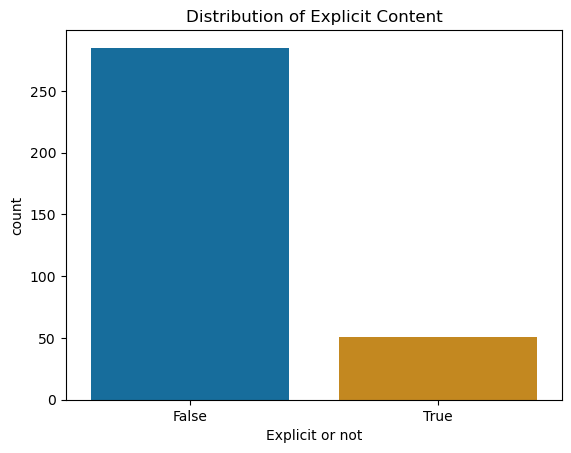

In [20]:
# Count plot for explicit content
sns.countplot(x='is_explicit', data=df, palette="colorblind")
plt.title('Distribution of Explicit Content')
plt.xlabel('Explicit or not')
plt.show()

## Musical Key

In [21]:
key_mapping = {
    0: 'C',
    1: 'C#/Db',
    2: 'D',
    3: 'D#/Eb',
    4: 'E',
    5: 'F',
    6: 'F#/Gb',
    7: 'G',
    8: 'G#/Ab',
    9: 'A',
    10: 'A#/Bb',
    11: 'B'
}

#create key name variable
df['key_name'] = df['key'].map(key_mapping)
#frequencies of each key name
key_name_frequencies = df['key_name'].value_counts().index

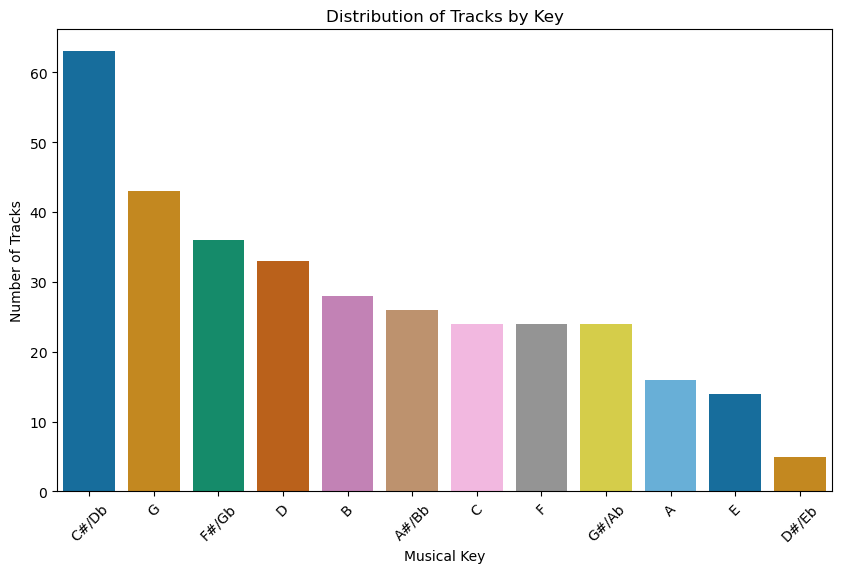

In [22]:
# Plot
plt.figure(figsize=(10, 6))
sns.countplot(x='key_name', data=df, palette='colorblind', order=key_name_frequencies)
plt.title('Distribution of Tracks by Key')
plt.xlabel('Musical Key')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.show()

## Correlation bw numeric attributes

In [23]:
num_col = ['danceability', 'valence', 'energy',
       'loudness', 'acousticness', 'instrumentalness', 'liveness',
       'speechiness','tempo','duration_ms']

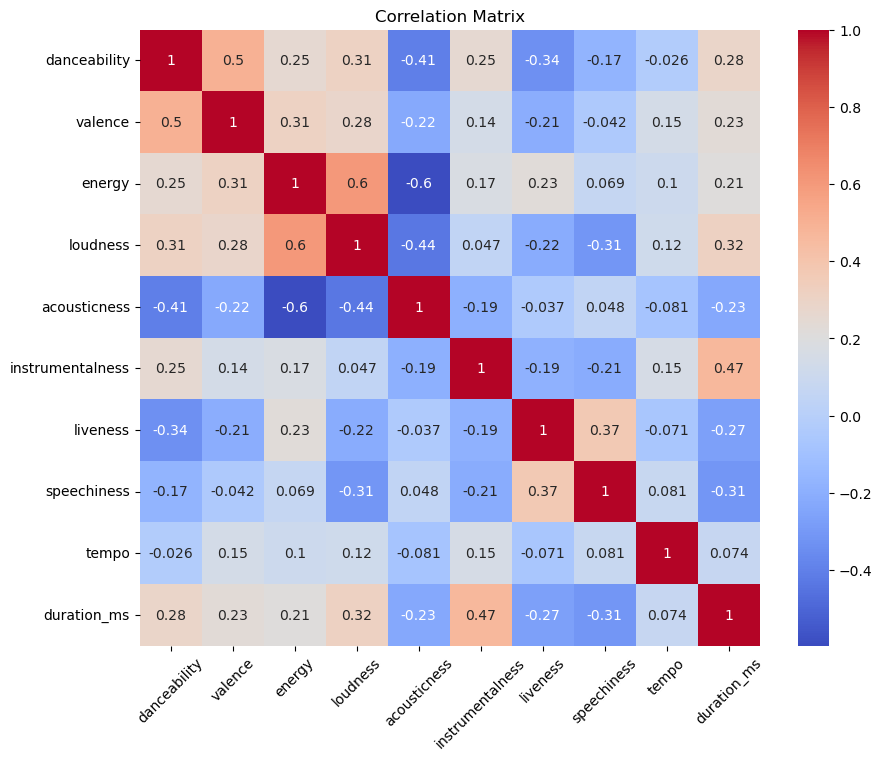

In [29]:
corr_matrix = df[num_col].corr()

plt.figure(figsize = (10,8))
sns.heatmap(corr_matrix, annot = True,cmap='coolwarm')
plt.xticks(rotation=45)
plt.title('Correlation Matrix')
plt.show()

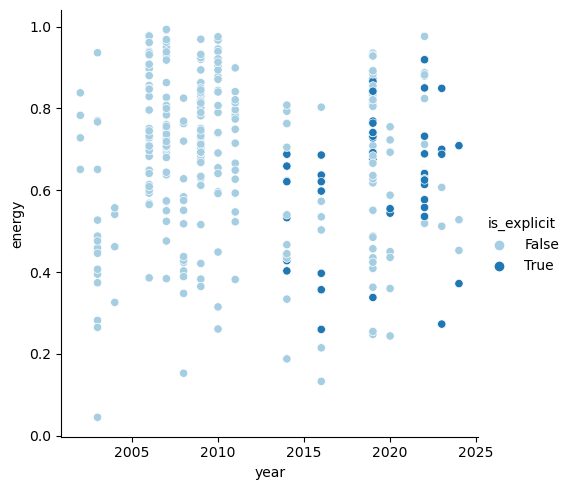

In [27]:
sns.relplot(x = 'year', y = 'energy', hue ='is_explicit' ,data = df)

## Attribution Comparision Radar Chart

##### Comparing Beyonce's past tracks to the latest track "TEXAS HOLD 'EM"
##### This radar chart visualizes what it means in music attributes to shift the music genre, from Pop, R&B to Country.

In [30]:
# Calculate the mean of the selected attributes for all tracks
attributes = ['danceability', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']
mean_attributes = df[attributes].mean()

# Extract the same attributes for the latest track
df['track_name'] = df['track_name'].str.strip()
specific_track_attributes = df[df['track_name'] == "TEXAS HOLD 'EM"][attributes].iloc[0]

# Convert series to list for plotting
means_values_all = mean_attributes.tolist()
specific_track_values = specific_track_attributes.tolist()

# Define colors for visual distinction
color_mean = '#1f77b4'  
color_specific_track = '#ff7f0e'  

# Create the radar chart
fig = go.Figure()

# Add trace for the mean attributes of all tracks
fig.add_trace(go.Scatterpolar(
    r=means_values_all,
    theta=attributes,
    fill='toself',
    name='Mean Attributes',
    fillcolor=color_mean,
    line=dict(color=color_mean),
    opacity=0.7
))

# Add trace for the "16 Carriage" track attributes
fig.add_trace(go.Scatterpolar(
    r=specific_track_values,
    theta=attributes,
    fill='toself',
    name='"TEXAS HOLD EM" Attributes',
    fillcolor=color_specific_track,
    line=dict(color=color_specific_track, dash='dot'),
    opacity=0.8
))

# Fine-tuning the layout
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]  
        )),
    title={
        'text': 'Comparison of Mean Track Attributes vs "TEXAS HOLD EM"',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    showlegend=True
)

fig.show()

## Album Analysis

### Attributes by Album

In [34]:
#Grouping by album_name and caluculating mean for numerical attributes
album_means = df.groupby('album_name')[num_col].mean().reset_index()
#Display the DataFrame
album_means[['album_name', 'danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']
]

,album_name,danceability,energy,acousticness,valence,speechiness,instrumentalness
0,16 CARRIAGES,0.525000,0.453000,0.382000,0.382000,0.063400,0.000000
1,4,0.604286,0.701429,0.175597,0.526143,0.120314,0.000444
2,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),0.784000,0.700000,0.011200,0.204000,0.039600,0.000018
3,Above And Beyoncé Dance Mixes,0.715000,0.724625,0.031791,0.618788,0.099400,0.272532
4,At Last,0.242000,0.438000,0.519000,0.559000,0.069400,0.005230
5,B'Day,0.653455,0.694182,0.112998,0.547727,0.261627,0.000922
6,B'Day Deluxe Edition,0.619174,0.701739,0.151380,0.501739,0.180030,0.000383
7,BEYONCÉ [Platinum Edition],0.562700,0.553550,0.193354,0.374385,0.138630,0.005367
8,BREAK MY SOUL REMIXES,0.771500,0.890250,0.004229,0.594000,0.098700,0.139407
9,Beautiful Liar,0.726250,0.697000,0.030769,0.495250,0.074675,0.234937


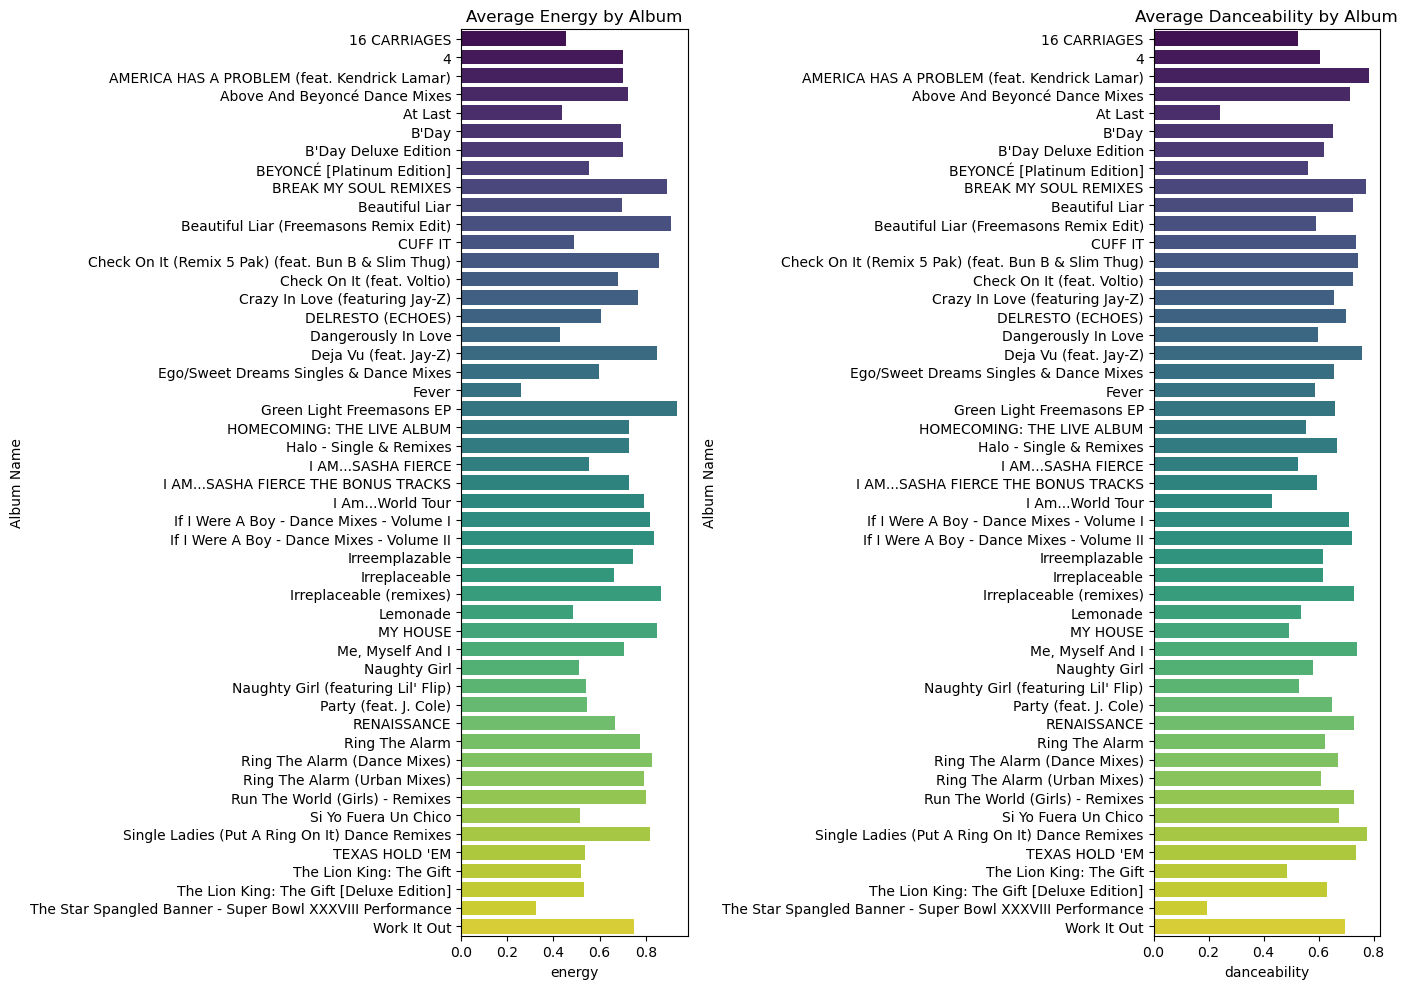

In [37]:
# Set the figure size for better readability
plt.figure(figsize=(14, 10))

# Subplot 1: Energy
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.barplot(x='energy', y='album_name', data=album_means, palette='viridis')
plt.title('Average Energy by Album')
plt.ylabel('Album Name')

# Subplot 2: Danceability
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.barplot(x='danceability', y='album_name', data=album_means, palette='viridis')
plt.title('Average Danceability by Album')
plt.ylabel('Album Name')

plt.tight_layout() 
plt.show()

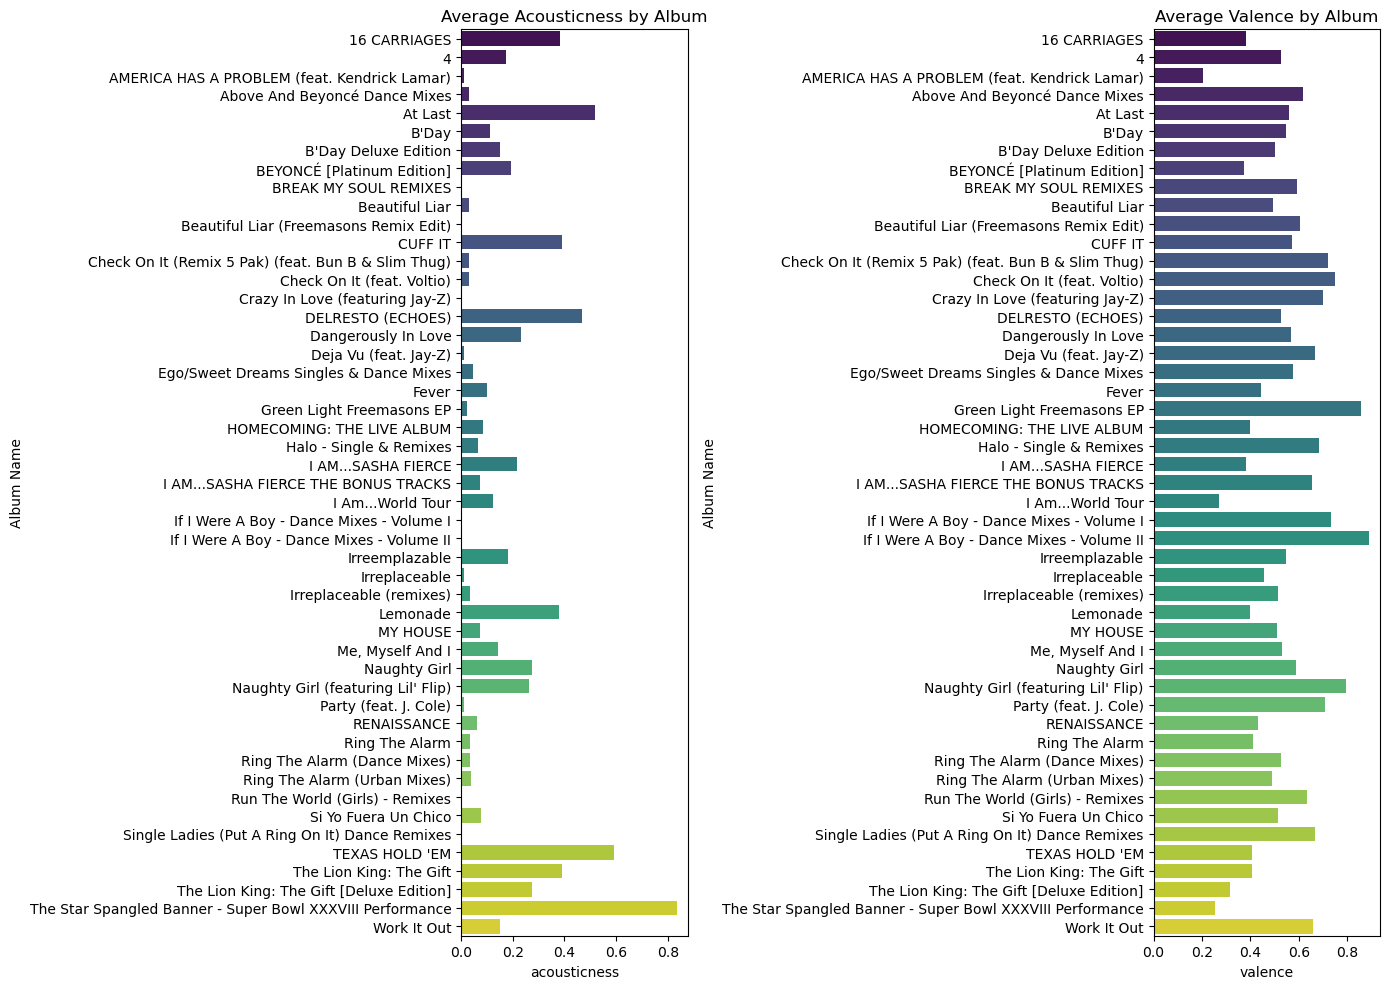

In [38]:
# Set the figure size for better readability
plt.figure(figsize=(14, 10))

# Subplot 1: Acousticness
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.barplot(x='acousticness', y='album_name', data=album_means, palette='viridis')
plt.title('Average Acousticness by Album')
plt.ylabel('Album Name')

# Subplot 2: Valence
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.barplot(x='valence', y='album_name', data=album_means, palette='viridis')
plt.title('Average Valence by Album')
plt.ylabel('Album Name')

plt.tight_layout()  
plt.show()

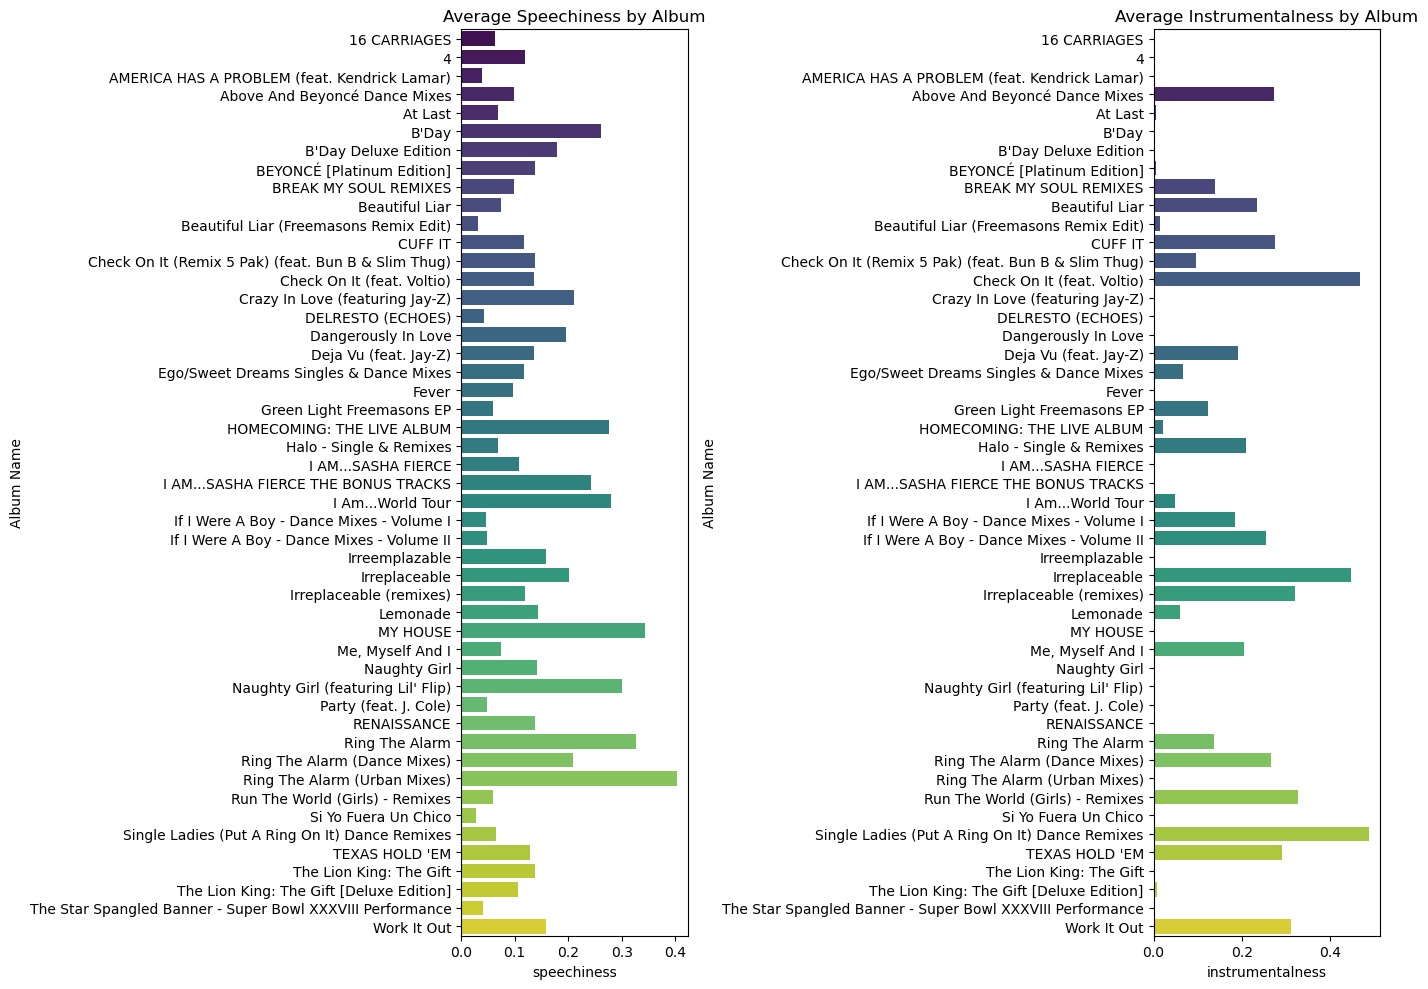

In [39]:
# Set the figure size for better readability
plt.figure(figsize=(14, 10))

# Subplot 1: Speechiness
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.barplot(x='speechiness', y='album_name', data=album_means, palette='viridis')
plt.title('Average Speechiness by Album')
plt.ylabel('Album Name')

# Subplot 2: Instrumentalness
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.barplot(x='instrumentalness', y='album_name', data=album_means, palette='viridis')
plt.title('Average Instrumentalness by Album')
plt.ylabel('Album Name')

plt.tight_layout()  
plt.show()

## Visualize Tempo by Album

In [41]:
tempo_duration = ['tempo','duration_ms']
# Calculating mean tempo and duration for each album
album_tempo_duration = df.groupby('album_name')[tempo_duration].mean().reset_index()
# Sort the DataFrame by 'tempo' in descending order
album_tempo_sorted = album_tempo_duration.sort_values('tempo', ascending=False)
# Display the DataFrame
#print(album_tempo_duration_sorted)

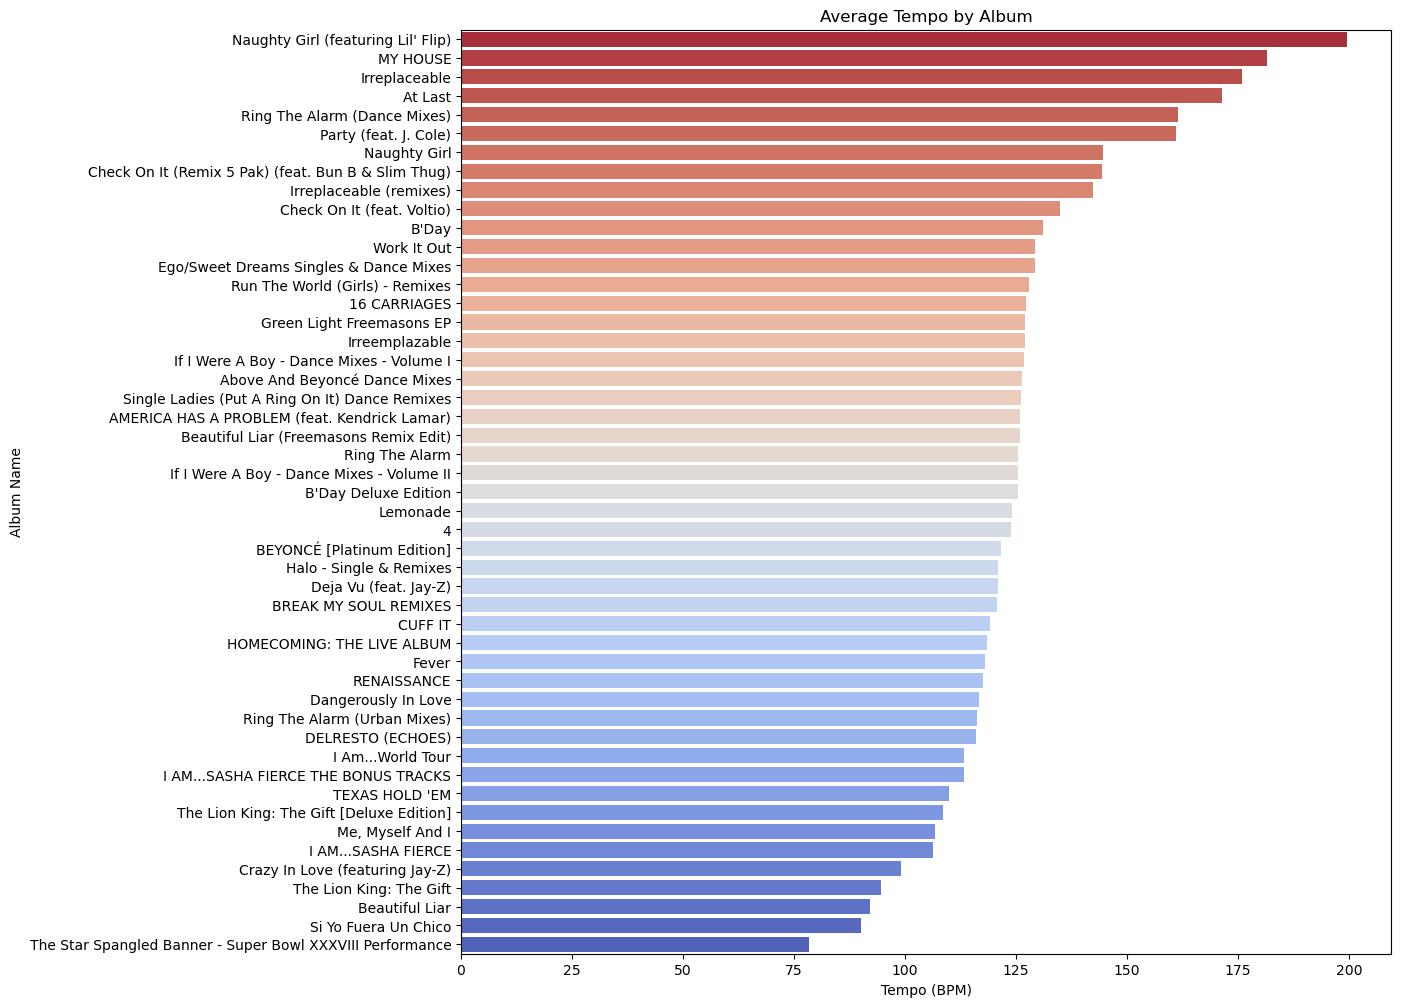

In [42]:
# Plot
plt.figure(figsize=(12, 12))
sns.barplot(x='tempo', y='album_name', data=album_tempo_sorted, palette='coolwarm_r')
plt.title('Average Tempo by Album')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Album Name')
plt.show()

## Visualize Duration by Album

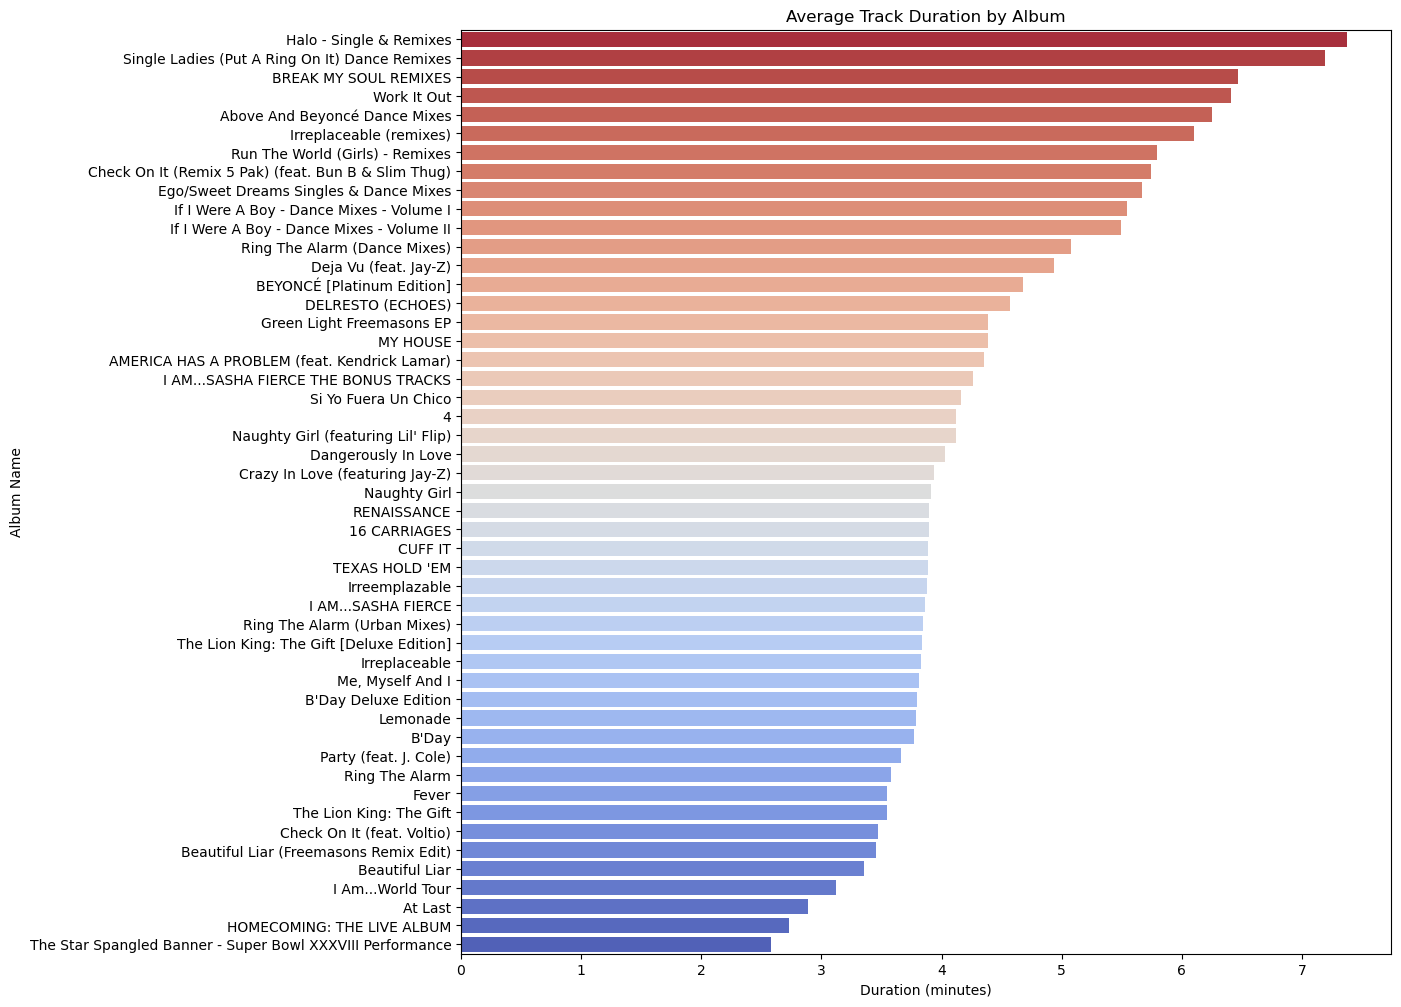

In [43]:
#Convert milliseconds to minutes and then sort
album_tempo_duration['duration_min'] = album_tempo_duration['duration_ms']/60000
album_duration_sorted = album_tempo_duration.sort_values('duration_min', ascending=False)

# Plot
plt.figure(figsize=(12,12))
sns.barplot(x='duration_min', y='album_name', data=album_duration_sorted, palette='coolwarm_r')
plt.title('Average Track Duration by Album')
plt.xlabel('Duration (minutes)')
plt.ylabel('Album Name')
plt.show()

## Add STD to the DataFrame

In [44]:
# Calculate standard deviation for 'tempo' and 'duration_ms' within each album
album_tempo_duration_std = df.groupby('album_name')[tempo_duration].std().reset_index()
# Rename columns for clarity
album_tempo_duration_std.rename(columns={'tempo': 'tempo_std', 'duration_ms': 'duration_ms_std'}, inplace=True)
# print(album_tempo_duration_std)

In [45]:
# Merge the mean and std DataFrames
album_analysis = pd.merge(album_tempo_duration, album_tempo_duration_std, on='album_name')

# Display the combined DataFrame
print(album_analysis)

                                           album_name       tempo  \
0                                        16 CARRIAGES  127.246000   
1                                                   4  123.973643   
2        AMERICA HAS A PROBLEM (feat. Kendrick Lamar)  126.015000   
3                       Above And Beyoncé Dance Mixes  126.377500   
4                                             At Last  171.357000   
5                                               B'Day  131.113273   
6                                B'Day Deluxe Edition  125.390565   
7                          BEYONCÉ [Platinum Edition]  121.736750   
8                               BREAK MY SOUL REMIXES  120.743000   
9                                      Beautiful Liar   92.224500   
10             Beautiful Liar (Freemasons Remix Edit)  125.984000   
11                                            CUFF IT  119.067667   
12  Check On It (Remix 5 Pak) (feat. Bun B & Slim ...  144.417800   
13                         Check O

## Visualizing Variability

### Error Bars: Visualizing Tempo Variability by Album

#### Error bars can extend from a central point (mean) to represent the variability or standard deviation. They are particularly useful in bar charts.

C:\Users\DELL-PC\anaconda3\lib\site-packages\numpy\core\_methods.py:45: RuntimeWarning:

invalid value encountered in reduce

C:\Users\DELL-PC\anaconda3\lib\site-packages\numpy\core\_methods.py:41: RuntimeWarning:

invalid value encountered in reduce



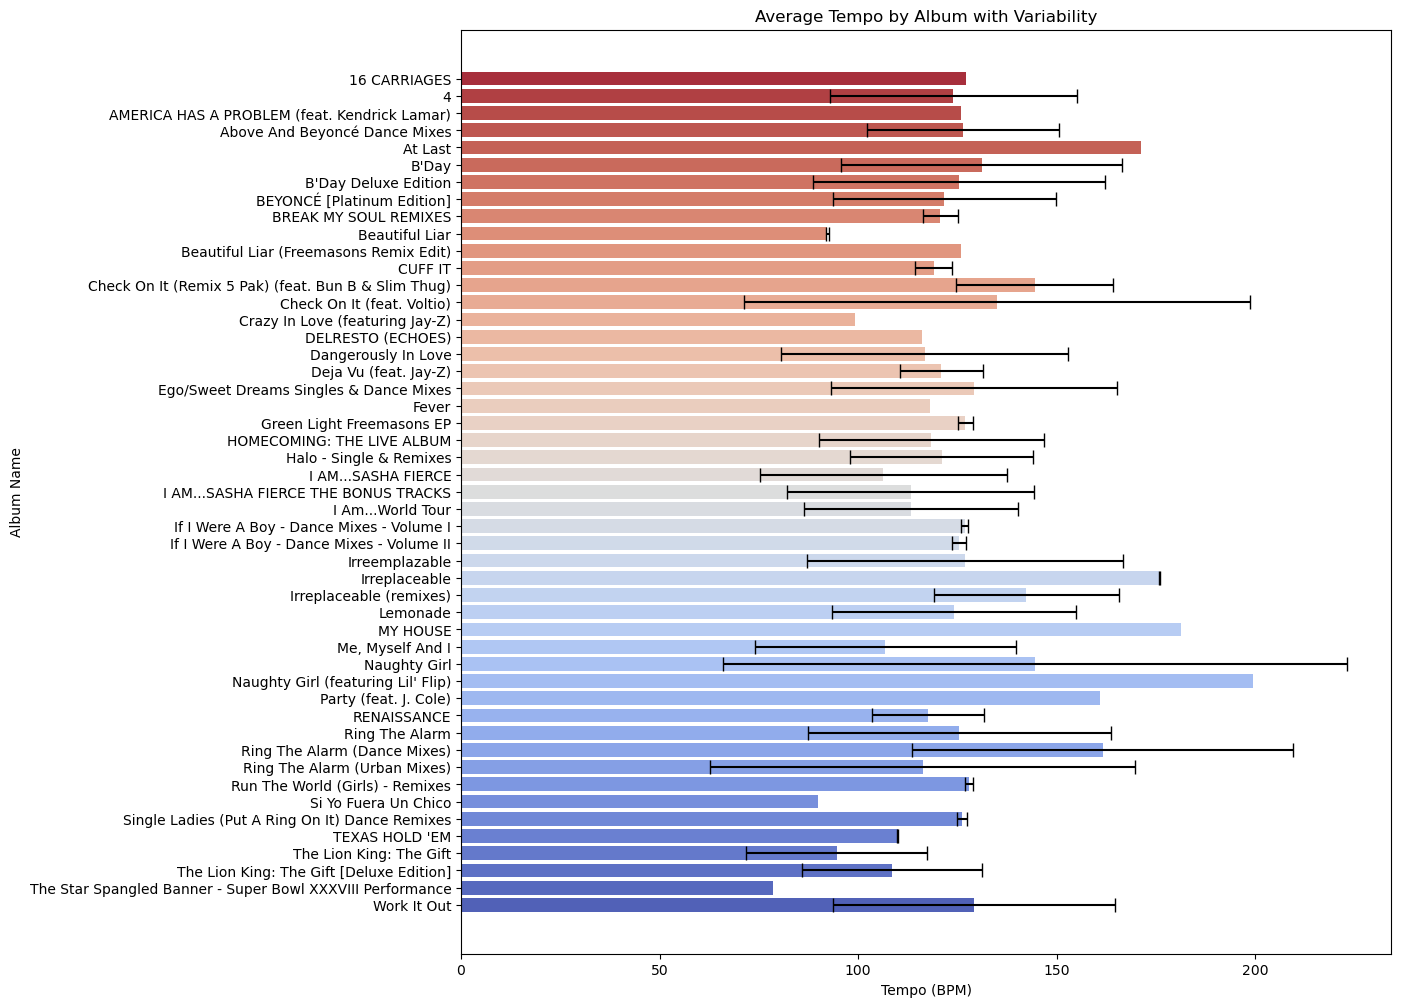

In [46]:
# Plot
plt.figure(figsize=(12, 12))
sns.barplot(x='tempo', y='album_name', data=album_means, palette='coolwarm_r', ci=None)
plt.errorbar(x=album_means['tempo'], y=range(len(album_means)), xerr=album_tempo_duration_std['tempo_std'], fmt='none', c='black', capsize=5)
plt.title('Average Tempo by Album with Variability')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Album Name')
plt.show()

## Box Plots

### Box plots are ideal for showing the distribution of data, indicating the median, quartiles, and outliers, which can give a sense of variability.

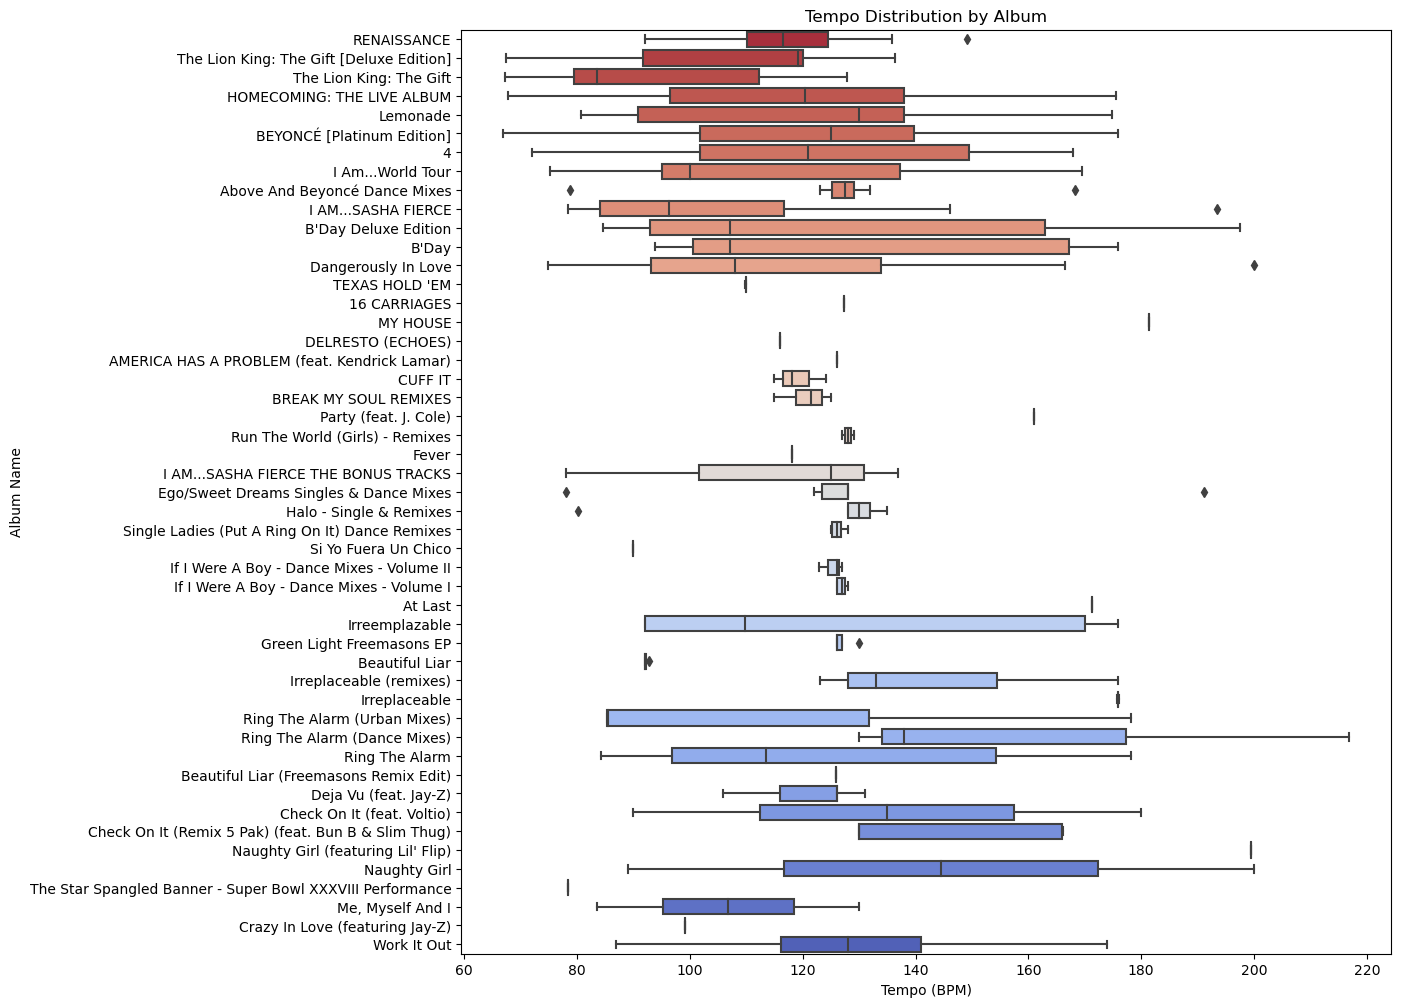

In [47]:
# Plot
plt.figure(figsize=(12,12))
sns.boxplot(x='tempo', y='album_name', data=df, palette='coolwarm_r')
plt.title('Tempo Distribution by Album')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Album Name')
plt.show()

## Overlaying a Strip Plot on a Bar Plot¶
### Combining a bar plot (showing the mean) with a strip plot (showing individual data points) can offer a clear view of both the average values and the variability around those averages.

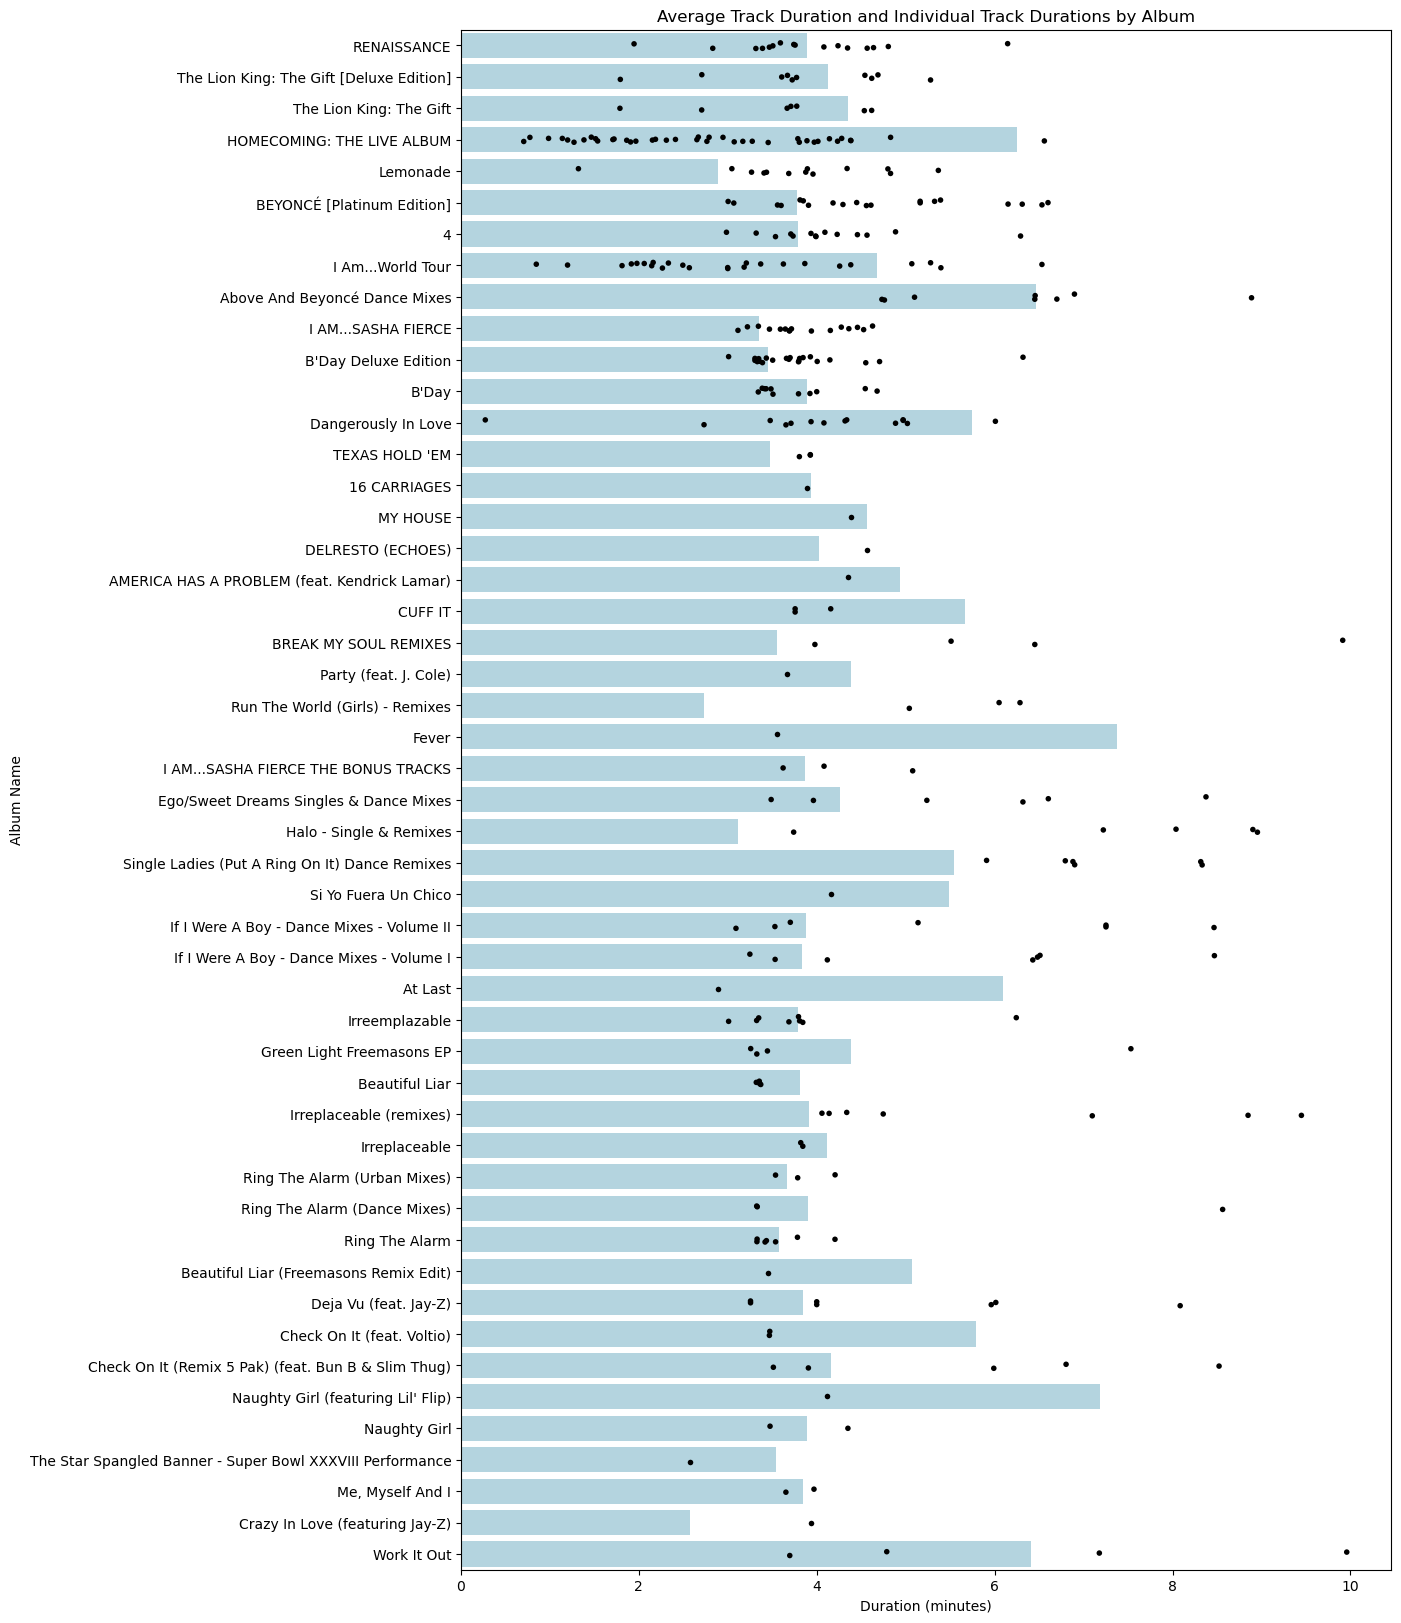

In [48]:
# Calculate mean duration in minutes
df['duration_min'] = df['duration_ms'] / 60000
album_duration_mean = df.groupby('album_name')['duration_min'].mean().reset_index()
plt.figure(figsize=(12, 20))
sns.barplot(x='duration_min', y='album_name', data=album_duration_mean, color='lightblue', ci=None)
sns.stripplot(x='duration_min', y='album_name', data=df, color='black', size=4, jitter=True)
plt.title('Average Track Duration and Individual Track Durations by Album')
plt.xlabel('Duration (minutes)')
plt.ylabel('Album Name')
plt.show()
